# Step 5: Risk-Adjusted Target Definition


In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(os.path.join('..', 'Src')))

from features.target_engineering import compute_forward_sharpe, create_binary_target, build_modeling_dataset

PROCESSED_DIR = os.path.join('..', 'Data', 'Processed')
FIGURES_DIR = os.path.join('..', 'Reports', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
print("Setup complete.")

Setup complete.


---
## 1. Load Validated Features

In [2]:
df = pd.read_csv(os.path.join(PROCESSED_DIR, 'validated_features.csv'), parse_dates=['date'])
df = df.sort_values(['ticker', 'date']).reset_index(drop=True)

print(f"Loaded: {len(df):,} rows")
print(f"Tickers: {df['ticker'].unique().tolist()}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"\nFeatures: {[c for c in df.columns if c not in ['date', 'ticker', 'log_return']]}")

Loaded: 7,820 rows
Tickers: ['AAPL', 'AMZN', 'GOOG', 'META', 'MSFT']
Date range: 2019-10-17 to 2026-01-07

Features: ['momentum_5d', 'excess_return', 'price_to_ma_21d', 'price_to_ma_50d', 'momentum_21d', 'roc', 'price_to_ma_200d', 'momentum_63d', 'momentum_126d', 'beta']


---
## 2. Compute Forward Sharpe Ratio

Formula: `Sharpe = (mean_fwd_return - rf) / std_fwd_return * sqrt(252)`



In [3]:
FORWARD_WINDOW = 21  # 1 month forward

# Compute forward Sharpe
df['fwd_sharpe'] = compute_forward_sharpe(df, window=FORWARD_WINDOW)

print(f"Forward Sharpe computed (window={FORWARD_WINDOW} days)")
print(f"\nDistribution:")
print(df['fwd_sharpe'].describe())

Forward Sharpe computed (window=21 days)

Distribution:
count    7620.000000
mean        1.109513
std         3.366633
min        -9.026148
25%        -1.263763
50%         1.177255
75%         3.445656
max        17.650978
Name: fwd_sharpe, dtype: float64


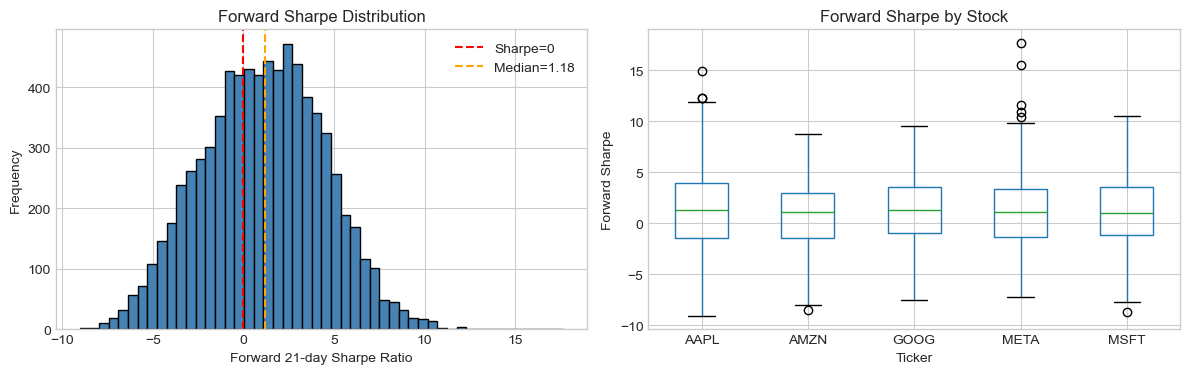

In [4]:
# Visualize forward Sharpe distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
ax1 = axes[0]
df['fwd_sharpe'].dropna().hist(bins=50, ax=ax1, color='steelblue', edgecolor='black')
ax1.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Sharpe=0')
ax1.axvline(df['fwd_sharpe'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median={df["fwd_sharpe"].median():.2f}')
ax1.set_xlabel('Forward 21-day Sharpe Ratio')
ax1.set_ylabel('Frequency')
ax1.set_title('Forward Sharpe Distribution')
ax1.legend()

# By ticker
ax2 = axes[1]
df.boxplot(column='fwd_sharpe', by='ticker', ax=ax2)
ax2.set_xlabel('Ticker')
ax2.set_ylabel('Forward Sharpe')
ax2.set_title('Forward Sharpe by Stock')
plt.suptitle('')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'forward_sharpe_dist.png'), dpi=150)
plt.show()

---
## 3. Create Binary Target


In [5]:
# Create binary target
median_sharpe = df['fwd_sharpe'].median()
df['target'] = create_binary_target(df['fwd_sharpe'], threshold='median')

print(f"Binary target created (threshold = median = {median_sharpe:.4f})")
print(f"\nClass distribution:")
print(df['target'].value_counts().sort_index())
print(f"\nBalance: {df['target'].mean()*100:.1f}% positive")

Binary target created (threshold = median = 1.1773)

Class distribution:
target
0    4010
1    3810
Name: count, dtype: int64

Balance: 48.7% positive


---
## 4. Verify No Leakage



In [6]:
# Feature columns (exclude meta and target)
EXCLUDE = ['date', 'ticker', 'log_return', 'fwd_sharpe', 'target']
feature_cols = [c for c in df.columns if c not in EXCLUDE]

# Check correlations with target
print("Feature correlations with target:")
print("(If any |corr| > 0.5, investigate for leakage!)\n")

target_corrs = df[feature_cols + ['target']].corr()['target'].drop('target').sort_values(key=abs, ascending=False)
for feat, corr in target_corrs.items():
    flag = " <-- INVESTIGATE" if abs(corr) > 0.3 else ""
    print(f"  {feat}: {corr:.4f}{flag}")

max_corr = target_corrs.abs().max()
print(f"\nMax |correlation|: {max_corr:.4f}")
print("Leakage check:", "PASS - correlations are weak" if max_corr < 0.3 else "WARNING - review features")

Feature correlations with target:
(If any |corr| > 0.5, investigate for leakage!)

  excess_return: 0.1643
  price_to_ma_50d: 0.0726
  momentum_5d: 0.0710
  price_to_ma_21d: 0.0547
  roc: 0.0501
  momentum_21d: 0.0495
  price_to_ma_200d: 0.0467
  momentum_126d: 0.0422
  momentum_63d: 0.0404
  beta: -0.0202

Max |correlation|: 0.1643
Leakage check: PASS - correlations are weak


---
## 5. Build Final Modeling Dataset

In [7]:
# Drop rows where target is NaN (end of each ticker's series)
df_clean = df.dropna(subset=['target']).reset_index(drop=True)

print(f"Rows before: {len(df):,}")
print(f"Rows after dropping NaN targets: {len(df_clean):,}")
print(f"Rows lost: {len(df) - len(df_clean):,} (expected: ~{FORWARD_WINDOW} per ticker)")

Rows before: 7,820
Rows after dropping NaN targets: 7,820
Rows lost: 0 (expected: ~21 per ticker)


In [8]:
# Final dataset structure
print("\n" + "="*60)
print("FINAL MODELING DATASET")
print("="*60)
print(f"\nShape: {df_clean.shape}")
print(f"\nColumns:")
print(f"  Metadata: date, ticker")
print(f"  Features ({len(feature_cols)}): {feature_cols}")
print(f"  Target: target (binary), fwd_sharpe (continuous)")
print(f"\nClass balance: {df_clean['target'].mean()*100:.1f}% positive")
print("="*60)


FINAL MODELING DATASET

Shape: (7820, 15)

Columns:
  Metadata: date, ticker
  Features (10): ['momentum_5d', 'excess_return', 'price_to_ma_21d', 'price_to_ma_50d', 'momentum_21d', 'roc', 'price_to_ma_200d', 'momentum_63d', 'momentum_126d', 'beta']
  Target: target (binary), fwd_sharpe (continuous)

Class balance: 48.7% positive


In [9]:
# Preview
display(df_clean[['date', 'ticker'] + feature_cols[:3] + ['fwd_sharpe', 'target']].head(10))

,date,ticker,momentum_5d,excess_return,price_to_ma_21d,fwd_sharpe,target
0,2019-10-17,AAPL,0.022306,0.003810,1.043302,NaN,0
1,2019-10-18,AAPL,0.000846,0.004727,1.044904,NaN,0
2,2019-10-21,AAPL,0.019481,0.017129,1.057953,NaN,0
3,2019-10-22,AAPL,0.019526,-0.002354,1.050858,NaN,0
4,2019-10-23,AAPL,0.036901,0.013265,1.059327,NaN,0
5,2019-10-24,AAPL,0.034669,0.001578,1.056129,NaN,0
6,2019-10-25,AAPL,0.042119,0.012177,1.063277,NaN,0
7,2019-10-28,AAPL,0.034892,0.009903,1.067303,NaN,0
8,2019-10-29,AAPL,0.013782,-0.023463,1.038524,NaN,0
9,2019-10-30,AAPL,0.000329,-0.000186,1.034470,NaN,0


---
## 6. Save Outputs

In [10]:
# Save target labels (for reference)
target_path = os.path.join(PROCESSED_DIR, 'target_labels.csv')
df_clean[['date', 'ticker', 'fwd_sharpe', 'target']].to_csv(target_path, index=False)
print(f"Saved: {target_path}")

# Save full modeling dataset
dataset_path = os.path.join(PROCESSED_DIR, 'modeling_dataset.csv')
df_clean.to_csv(dataset_path, index=False)
print(f"Saved: {dataset_path}")

Saved: ..\Data\Processed\target_labels.csv
Saved: ..\Data\Processed\modeling_dataset.csv
